# Customer Churn Analysis for a Subscription Business


## 1. Objective

- Examine customer churn patterns within a subscription-based telecom dataset  
- Identify and quantify the primary drivers of customer attrition  
- Analyze the influence of contract structure, tenure, billing behavior, and service usage  
- Segment customers to highlight high-risk retention groups  
- Deliver actionable insights to support data-driven retention and business decisions   

## 2. Import Libraries

In [94]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load Dataset

In [95]:
file_path = r"C:\Users\vasis\Desktop\Data_Analytics_Portfolio\02_Customer_Churn\data_raw\customer_churn_raw.csv"
df = pd.read_csv(file_path)

## 4. Initial Data Inspection

In [96]:
df.head()
df.shape
df.info()
df.columns
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

np.int64(0)

In [97]:
df["customerID"].nunique()

7043

In [98]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [99]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [100]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [101]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

## 5. Data Cleaning

In [102]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [103]:
df["totalcharges"].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: totalcharges, dtype: str

In [104]:
df["totalcharges"].isna().sum()

np.int64(0)

In [105]:
df[df["totalcharges"].isna()][["tenure", "monthlycharges"]].head()

,tenure,monthlycharges


In [106]:
df["totalcharges"] = df["totalcharges"].replace(" ", pd.NA)
df["totalcharges"] = df["totalcharges"].astype(float)

In [107]:
df = df.dropna(subset=["totalcharges"]).copy()

In [108]:
df["totalcharges"].isna().sum()

np.int64(0)

In [109]:
df.shape
# TotalCharges contains blank values for customers with zero tenure.
# These rows are removed as they do not have complete billing information.

(7032, 21)

In [110]:
df["churn"] = df["churn"].map({"Yes": 1, "No": 0})

In [111]:
df["churn"].value_counts()

churn
0    5163
1    1869
Name: count, dtype: int64

## 6. Feature Engineering

In [112]:
#creating new columns

In [113]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"],
    include_lowest=True
)

In [114]:
df["monthly_charge_group"] = pd.cut(
    df["monthlycharges"],
    bins=[0, 35, 70, 120],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [115]:
df["monthly_charge_group"] = pd.cut(
    df["monthlycharges"],
    bins=[0, 35, 70, 120],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [116]:
df["churn_label"] = df["churn"].map({1: "Churned", 0: "Retained"})

## 7. Exploratory Data Analysis

In [117]:
churn_rate = df["churn"].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 26.58%


In [118]:
churn_by_contract = (
    df.groupby("contract", as_index=False)["churn"]
    .mean()
    .sort_values("churn", ascending=False)
)

churn_by_contract["churn"] = churn_by_contract["churn"] * 100
churn_by_contract

,contract,churn
0,Month-to-month,42.709677
1,One year,11.277174
2,Two year,2.848665


In [119]:
churn_by_tenure = (
    df.groupby("tenure_group", as_index=False)["churn"]
    .mean()
    .sort_values("churn", ascending=False)
)

churn_by_tenure["churn"] = churn_by_tenure["churn"] * 100
churn_by_tenure

,tenure_group,churn
0,0-12 Months,47.678161
1,13-24 Months,28.710938
2,25-48 Months,20.388959
3,49-72 Months,9.513176


In [120]:
churn_by_payment = (
    df.groupby("paymentmethod", as_index=False)["churn"]
    .mean()
    .sort_values("churn", ascending=False)
)

churn_by_payment["churn"] = churn_by_payment["churn"] * 100
churn_by_payment

,paymentmethod,churn
2,Electronic check,45.285412
3,Mailed check,19.201995
0,Bank transfer (automatic),16.731518
1,Credit card (automatic),15.253123


In [121]:
churn_by_internet = (
    df.groupby("internetservice", as_index=False)["churn"]
    .mean()
    .sort_values("churn", ascending=False)
)

churn_by_internet["churn"] = churn_by_internet["churn"] * 100
churn_by_internet

,internetservice,churn
1,Fiber optic,41.892765
0,DSL,18.998344
2,No,7.434211


In [122]:
churn_by_charge = (
    df.groupby("monthly_charge_group", as_index=False)["churn"]
    .mean()
    .sort_values("churn", ascending=False)
)

churn_by_charge["churn"] = churn_by_charge["churn"] * 100
churn_by_charge

,monthly_charge_group,churn
2,High,35.381178
1,Medium,23.983740
0,Low,10.931174


In [123]:
churn_by_senior = (
    df.groupby("seniorcitizen", as_index=False)["churn"]
    .mean()
    .sort_values("churn", ascending=False)
)

churn_by_senior["churn"] = churn_by_senior["churn"] * 100
churn_by_senior

,seniorcitizen,churn
1,1,41.681261
0,0,23.650255


In [124]:
churn_by_billing = (
    df.groupby("paperlessbilling", as_index=False)["churn"]
    .mean()
    .sort_values("churn", ascending=False)
)

churn_by_billing["churn"] = churn_by_billing["churn"] * 100
churn_by_billing

,paperlessbilling,churn
1,Yes,33.589251
0,No,16.375698


## 8. Business Insights

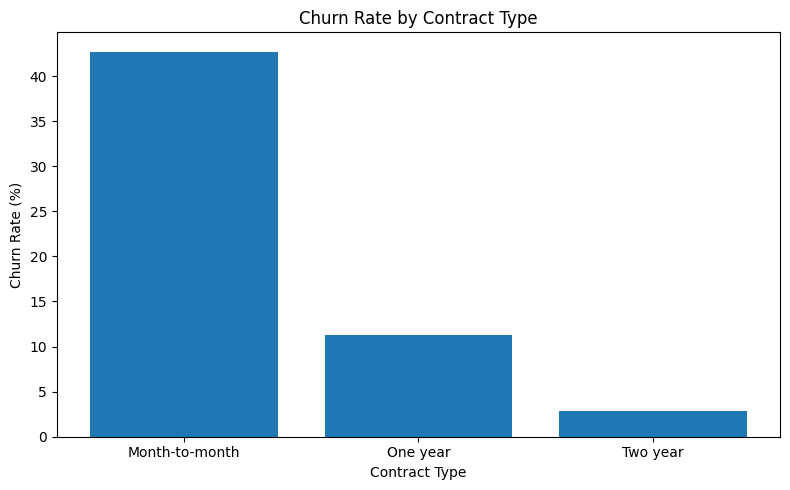

In [125]:
plt.figure(figsize=(8, 5))
plt.bar(churn_by_contract["contract"], churn_by_contract["churn"])
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

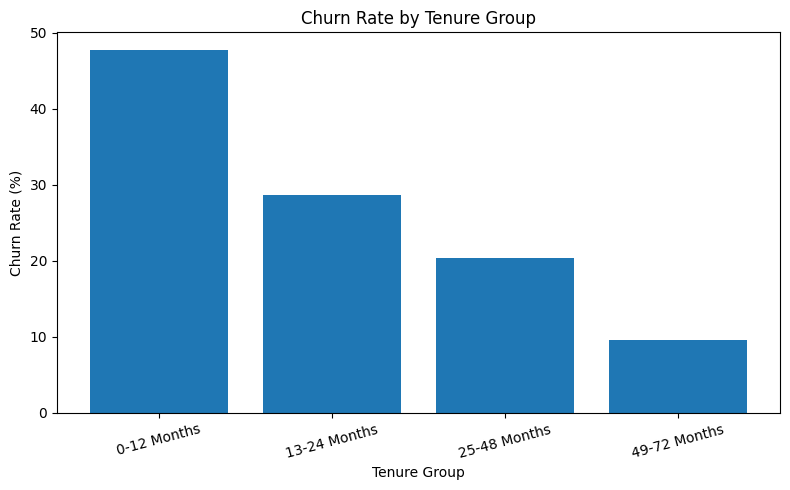

In [126]:
plt.figure(figsize=(8, 5))
plt.bar(churn_by_tenure["tenure_group"].astype(str), churn_by_tenure["churn"])
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

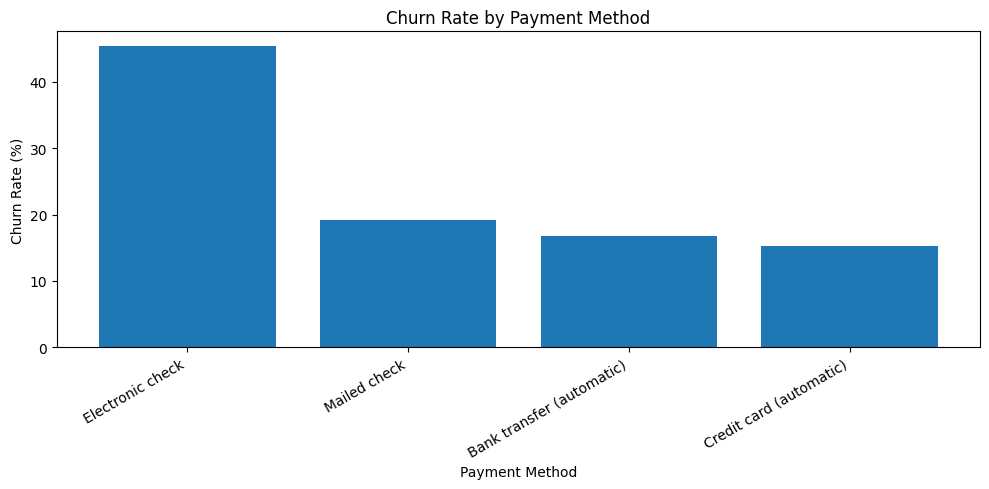

In [127]:
plt.figure(figsize=(10, 5))
plt.bar(churn_by_payment["paymentmethod"], churn_by_payment["churn"])
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

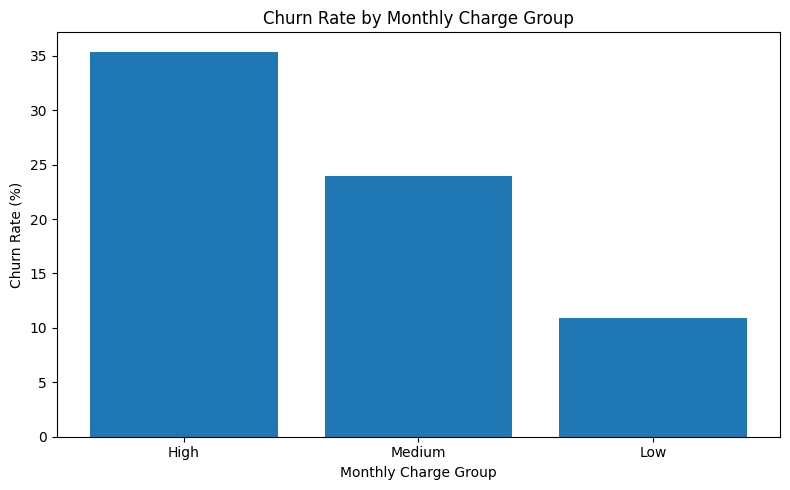

In [128]:
plt.figure(figsize=(8, 5))
plt.bar(churn_by_charge["monthly_charge_group"].astype(str), churn_by_charge["churn"])
plt.title("Churn Rate by Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

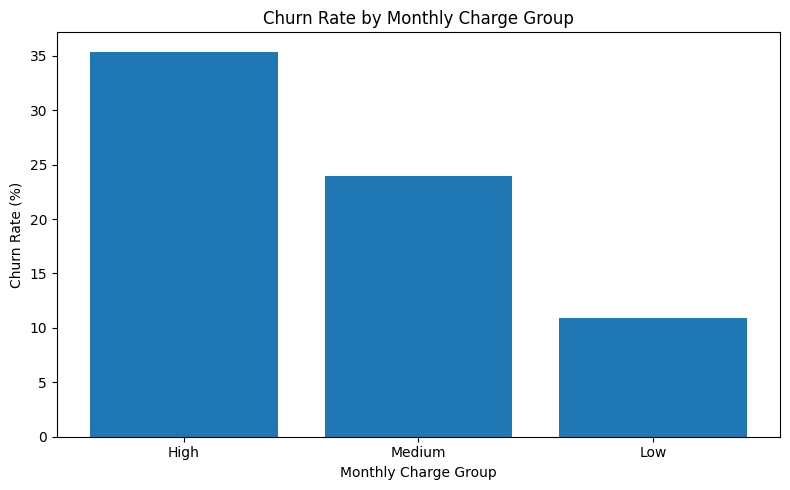

In [129]:
plt.figure(figsize=(8, 5))
plt.bar(churn_by_charge["monthly_charge_group"].astype(str), churn_by_charge["churn"])
plt.title("Churn Rate by Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

## Business Insights

- Month-to-month customers show the highest churn rate, indicating that shorter contract commitments are associated with greater customer loss.
- Churn is highest among low-tenure customers, suggesting that the first year is the most critical retention period.
- Customers in the high monthly charge segment are more likely to churn, which may reflect price sensitivity.
- Certain payment methods appear to be associated with higher churn, which may indicate billing friction or customer preference patterns.
- Long-term contract customers are significantly more stable and have lower churn risk.

## Recommendations

- Encourage month-to-month customers to move to longer-term plans through targeted discounts or bundled offers.
- Strengthen onboarding and customer support for new customers during the first 12 months.
- Monitor high-charge customer segments more closely and offer proactive retention incentives.
- Review payment experience for high-churn billing segments and simplify billing where possible.

## 9. Export Cleaned Data

In [132]:
output_path = r"C:\Users\vasis\Desktop\Data_Analytics_Portfolio\02_Customer_Churn\data_cleaned\customer_churn_cleaned.csv"
df.to_csv(output_path, index=False)